# Лабораторная работа №1. Разведочный анализ данных. Исследование и визуализация данных.

## 1) Текстовое описание набора данных
В качестве набора данных используется датасет "Popular Video Games 1980-2023".
Данный набор содержит информацию о популярных видеоиграх, включая их рейтинги, количество игроков, жанры и отзывы. 

**Основные колонки:**
- `Title`: Название игры.
- `Release Date`: Дата выхода.
- `Rating`: Средний рейтинг игры.
- `Plays`: Количество людей, игравших в игру.
- `Wishlist`: Количество добавлений в список желаемого.
- `Genres`: Список жанров.

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 

# Настройка визуализации
sns.set_style(style="ticks")

In [28]:
# Загрузите файл (убедитесь, что он лежит в той же папке)
df = pd.read_csv("games.csv", index_col=0)
# Первые 5 строк
print("Первые 5 строк датасета:")
display(df.head())

# Основные характеристики
print("\nИнформация о колонках и типах данных:")
df.info()

# Проверка пропусков
print("\nКоличество пропусков в данных:")
print(df.isnull().sum())
print(f"Размер датасета: {df.shape}")

Первые 5 строк датасета:


,Title,Release Date,Team,Rating,Times Listed,Number of Reviews,Genres,Summary,Reviews,Plays,Playing,Backlogs,Wishlist
0,Elden Ring,"Feb 25, 2022","['Bandai Namco Entertainment', 'FromSoftware']",4.5,3.9K,3.9K,"['Adventure', 'RPG']","Elden Ring is a fantasy, action and open world...","[""The first playthrough of elden ring is one o...",17K,3.8K,4.6K,4.8K
1,Hades,"Dec 10, 2019",['Supergiant Games'],4.3,2.9K,2.9K,"['Adventure', 'Brawler', 'Indie', 'RPG']",A rogue-lite hack and slash dungeon crawler in...,['convinced this is a roguelike for people who...,21K,3.2K,6.3K,3.6K
2,The Legend of Zelda: Breath of the Wild,"Mar 03, 2017","['Nintendo', 'Nintendo EPD Production Group No...",4.4,4.3K,4.3K,"['Adventure', 'RPG']",The Legend of Zelda: Breath of the Wild is the...,['This game is the game (that is not CS:GO) th...,30K,2.5K,5K,2.6K
3,Undertale,"Sep 15, 2015","['tobyfox', '8-4']",4.2,3.5K,3.5K,"['Adventure', 'Indie', 'RPG', 'Turn Based Stra...","A small child falls into the Underground, wher...",['soundtrack is tied for #1 with nier automata...,28K,679,4.9K,1.8K
4,Hollow Knight,"Feb 24, 2017",['Team Cherry'],4.4,3K,3K,"['Adventure', 'Indie', 'Platform']",A 2D metroidvania with an emphasis on close co...,"[""this games worldbuilding is incredible, with...",21K,2.4K,8.3K,2.3K



Информация о колонках и типах данных:
<class 'pandas.core.frame.DataFrame'>
Index: 1512 entries, 0 to 1511
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              1512 non-null   object 
 1   Release Date       1512 non-null   object 
 2   Team               1511 non-null   object 
 3   Rating             1499 non-null   float64
 4   Times Listed       1512 non-null   object 
 5   Number of Reviews  1512 non-null   object 
 6   Genres             1512 non-null   object 
 7   Summary            1511 non-null   object 
 8   Reviews            1512 non-null   object 
 9   Plays              1512 non-null   object 
 10  Playing            1512 non-null   object 
 11  Backlogs           1512 non-null   object 
 12  Wishlist           1512 non-null   object 
dtypes: float64(1), object(12)
memory usage: 165.4+ KB

Количество пропусков в данных:
Title                 0
Release Date          0
Team

In [29]:
def clean_numeric(x):
    if isinstance(x, str):
        if "K" in x:
            return float(x.replace("K", "")) * 1000
        return float(x)
    return x


# Очищаем колонки с числами
cols_to_fix = ["Plays", "Playing", "Backlogs", "Wishlist"]
for col in cols_to_fix:
    df[col] = df[col].apply(clean_numeric)

# Удаляем строки с пропусками в рейтинге, если они есть
df = df.dropna(subset=["Rating"])

print("Данные после очистки:")
display(df[cols_to_fix + ["Rating"]].describe())

Данные после очистки:


,Plays,Playing,Backlogs,Wishlist,Rating
count,1499.000000,1499.000000,1499.000000,1499.000000,1499.000000
mean,6307.694463,269.676451,1462.428286,777.693796,3.719346
std,5891.645858,427.582310,1343.029151,793.790867,0.532608
min,1.000000,0.000000,5.000000,2.000000,0.700000
25%,1900.000000,44.000000,470.000000,212.000000,3.400000
50%,4300.000000,115.000000,1000.000000,496.000000,3.800000
75%,9100.000000,302.000000,2100.000000,1100.000000,4.100000
max,33000.000000,3800.000000,8300.000000,4800.000000,4.800000


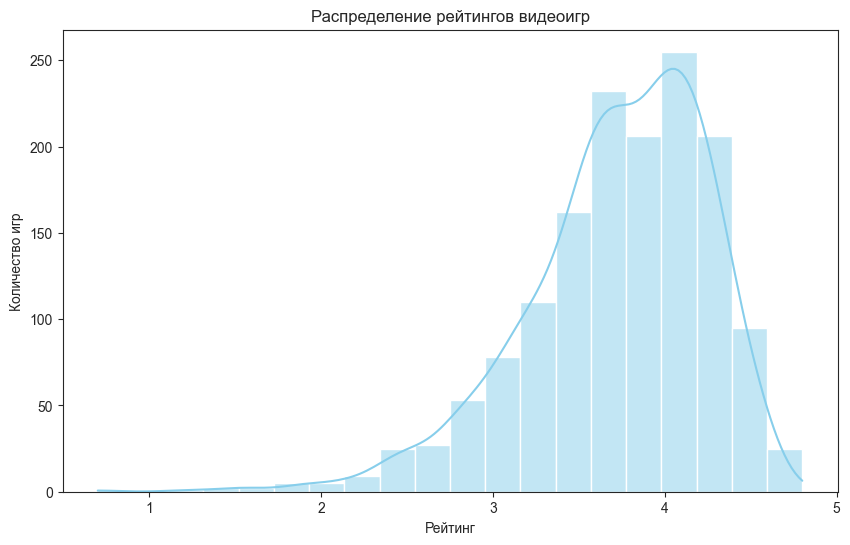

In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["Rating"], bins=20, kde=True, color="skyblue")
plt.title("Распределение рейтингов видеоигр")
plt.xlabel("Рейтинг")
plt.ylabel("Количество игр")
plt.show()

Большинство видеоигр имеют оценку выше 3.0, что указывает на то, что в датасет попали преимущественно успешные проекты.

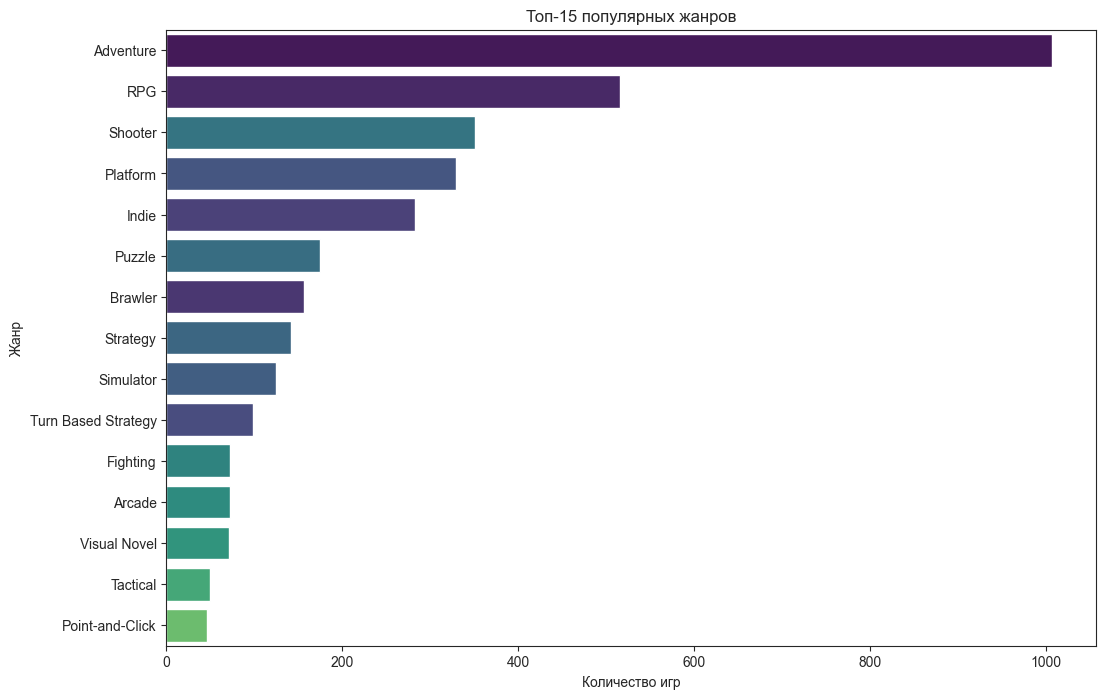

In [31]:
# Ячейка 6: Визуальное исследование — Жанры (ИСПРАВЛЕННАЯ)
import ast

# 1. Превращаем строку '[RPG, Strategy]' в настоящий список
# Добавим проверку на корректность данных, чтобы избежать ошибок
df["Genres_list"] = df["Genres"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)

# 2. "Взрываем" список и СРАЗУ сбрасываем индекс (.reset_index)
# Это удалит старые дублирующиеся ID строк и создаст новые уникальные
genres_exploded = df.explode("Genres_list").reset_index(drop=True)

# 3. Удаляем пустые значения, если они появились после explode
genres_exploded = genres_exploded.dropna(subset=["Genres_list"])

# 4. Строим график
plt.figure(figsize=(12, 8))
sns.countplot(
    data=genres_exploded,
    y="Genres_list",
    hue="Genres_list",
    order=genres_exploded["Genres_list"].value_counts().index[:15],
    palette="viridis",  # Добавим цвета для красоты
)

plt.title("Топ-15 популярных жанров")
plt.xlabel("Количество игр")
plt.ylabel("Жанр")
plt.show()

Жанры Adventure и RPG являются наиболее представленными в данном наборе данных.

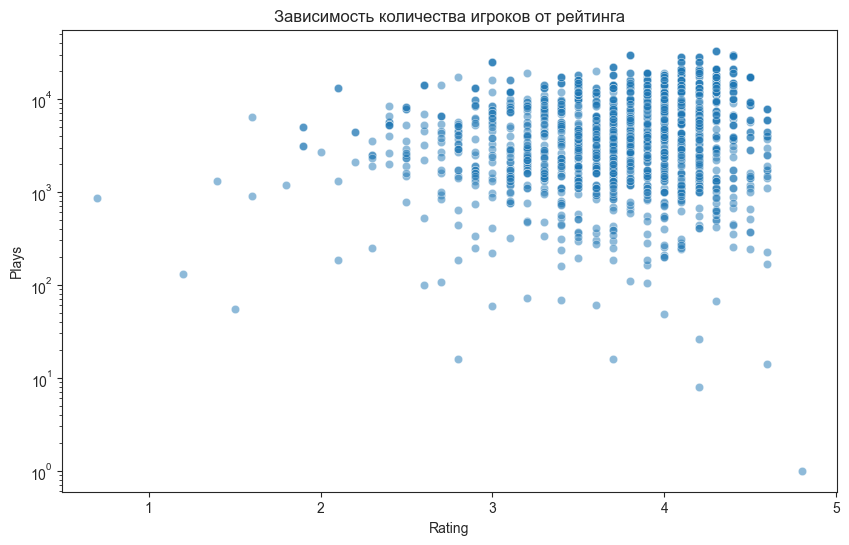

In [32]:
# Посмотрим, как рейтинг зависит от количества игроков
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Rating", y="Plays", alpha=0.5)
plt.yscale("log")  # Используем логарифмическую шкалу, так как разброс игроков огромный
plt.title("Зависимость количества игроков от рейтинга")
plt.show()

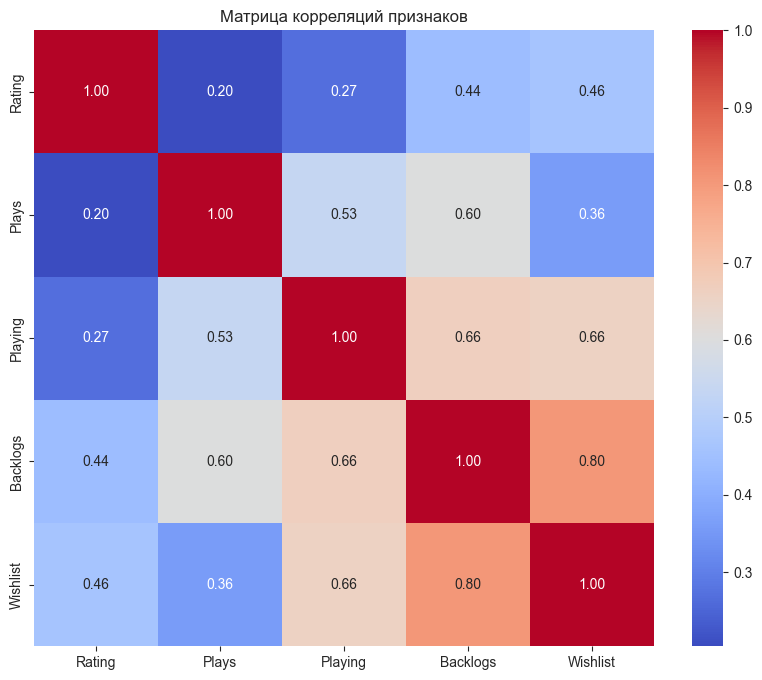

In [33]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матрица корреляций признаков")
plt.show()

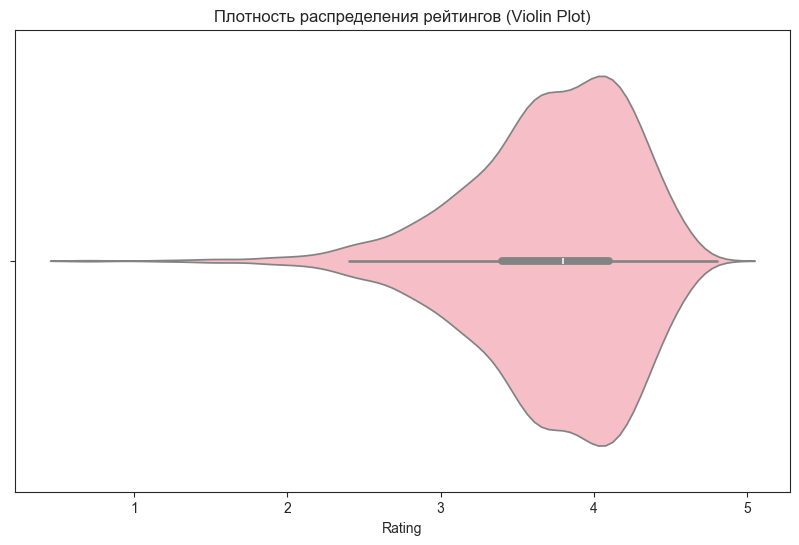

In [34]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=df["Rating"], color="lightpink")
plt.title("Плотность распределения рейтингов (Violin Plot)")
plt.show()